In [ ]:
from google.colab import files
uploaded=files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
# STEP 1:IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
# STEP 2:LOAD DATASET
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# STEP 3:Understand dataset
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# STEP 4:CHECK MISSING VALUES AND DUPLICATES
df.isnull().sum()
df.duplicated().sum()
# df=df.drop_duplicates()



np.int64(0)

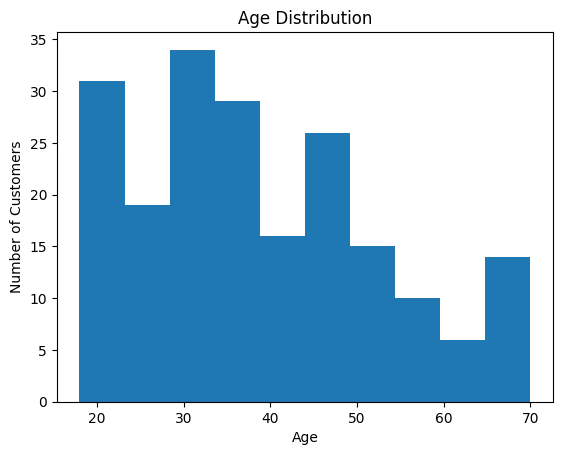

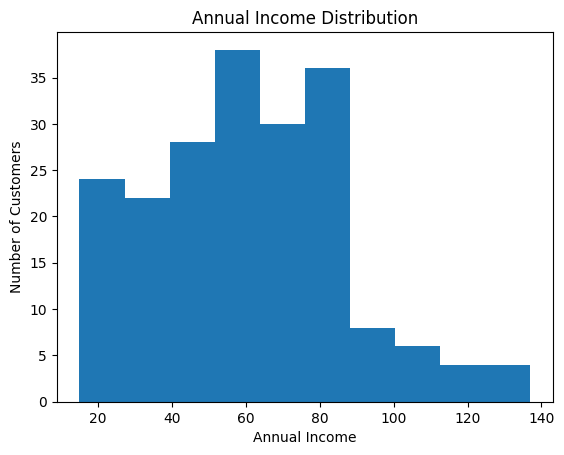

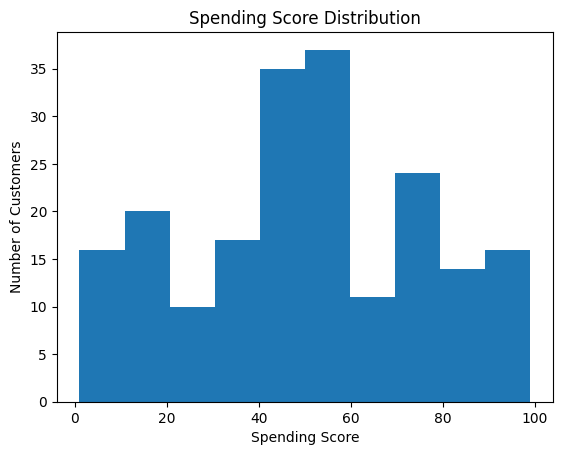

In [ ]:
# STEP 5:EXPLORATORY DATA ANALYSIS
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.show()

plt.hist(df["Annual Income (k$)"], bins=10)
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.title("Annual Income Distribution")
plt.show()

plt.hist(df["Spending Score (1-100)"], bins=10)
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.title("Spending Score Distribution")
plt.show()

In [ ]:
# STEP 6:SELECT Feature
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]


In [ ]:
# STEP 7:DATA scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

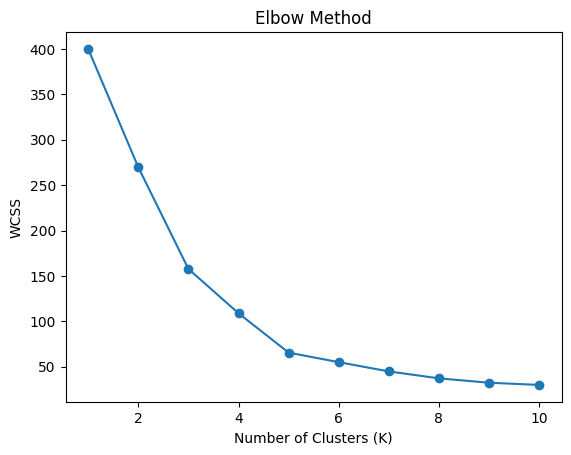

In [ ]:
# STEP 8:Elbow Method
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [ ]:
# STEP 9:Train K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)


In [ ]:
# STEP 10:Add clusters labels
df["Cluster"] = clusters
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


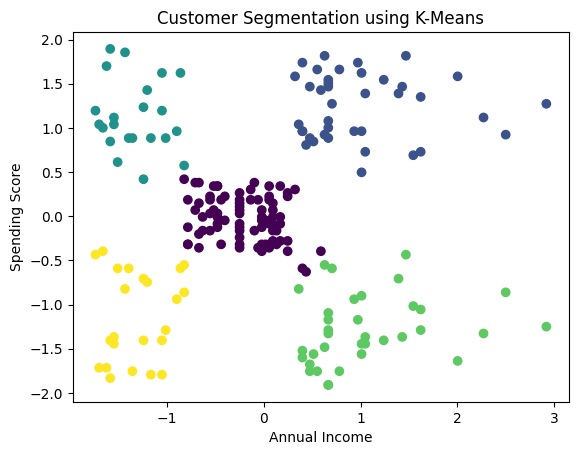

In [ ]:
# STEP 11:visualize clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()


In [ ]:
# Step 12:analyze each cluster
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [ ]:
# STEP 13:New Customer Segmentation
new_customer = np.array([[80,75]])
new_customer_scaled = scaler.transform(new_customer)
cluster = kmeans.predict(new_customer_scaled)
print("Customer belongs to Cluster:",cluster[0])

Customer belongs to Cluster: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
